In [2]:
import pandas as pd
import numpy as np

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
# Загружаем датасеты из двух источников

hh=pd.read_csv('df_hh_rich.csv')
sj=pd.read_csv('df_sj_api.csv')

In [81]:
hh.head(1)

,title_x,address,company,short_description,experience,salary,region__title,country_title,client_staff_count,salary_num
0,Разработчик,Москва,"Русская Медиагруппа, радиохолдинг",Опыт работы,Опыт 3-6 лет,NaN,Московская область,Россия,NaN,NaN


In [82]:
sj.head(1)

,profession,currency,vacancyRichText,education,experience,firm_name,town_name,region__title,country_title,client_staff_count,position,salary
0,Дежурный специалист по информационной безопасн...,rub,"ФФКУ ""Налог-Сервис"" ФНС России по ЦОД- это пр...",Не имеет значения,От 1 года,Филиал ФКУ Налог-Сервис ФНС России по ЦОД в г....,Уфа,Республика Башкортостан,Россия,100 — 500,"['Другое', 'Информационная безопасность']",0.0


In [83]:
sj['currency'].unique()

array(['rub', 'kzt'], dtype=object)

In [130]:
sj[sj['currency']=='kzt']

,profession,currency,vacancyRichText,education,experience,firm_name,town_name,region__title,country_title,client_staff_count,position,salary
264,Senior Kotlin разработчик,kzt,"Привет! Мы — Антара , аккредитованная IT-комп...",Не имеет значения,От 3 лет,Антара,Алматы,NaN,Казахстан,100 — 500,"['Разработка, программирование']",1600000.0


In [131]:
# вручную переведем по текущему курсу из тенге в рубли

sj.loc[264, 'salary'] = 256640.0

Теперь все вакансии в рублях, как и у хх.ру, поэтому можно удалить столбец currency из  sj.

Удалим также столбцы town_name в sj и address, тк мы специально добавляли регионы и страны, чтобы по ним анализировать в едином виде.

Удалим столбец salary из hh, тк мы преобразовали его в более полезный числовой salary_num и position, тк он есть только в sj и не является ценным для гипотез в таком небольшом объеме (в отличие от education - требования к образованию).

In [132]:
sj=sj.drop(columns=['currency','town_name','position'])
hh=hh.drop(columns=['address','salary'])

# Приводим названия признаков к единому виду

In [133]:
hh=hh.rename(columns={
    'title_x': 'profession',
    'salary_num': 'salary',
    'short_description':'vac_description',
    'region__title':'region',
    'country_title':'country',
    'client_staff_count':'company_staff_count',
})

sj=sj.rename(columns={
    'vacancyRichText':'vac_description',
    'firm_name':'company',
    'region__title':'region',
    'country_title':'country',
    'client_staff_count':'company_staff_count',
})

# Соединяем датасеты

In [134]:
final_df = pd.concat([hh, sj], ignore_index=True)
final_df.head()

,profession,company,vac_description,experience,region,country,company_staff_count,salary,education
0,Разработчик,"Русская Медиагруппа, радиохолдинг",Опыт работы,Опыт 3-6 лет,Московская область,Россия,NaN,NaN,NaN
1,Разработчик,Детский хоспис Дом с маяком,"Уверенное знание Python 3, базовых принципов О...",Опыт 1-3 года,Московская область,Россия,NaN,95000.0,NaN
2,Backend-разработчик,ООО ГК СтиС,2+ года коммерческой разработки на PHP 7.4+. У...,Опыт 1-3 года,Московская область,Россия,NaN,NaN,NaN
3,Разработчик ЦФТ,Bell Integrator,Опыт работы с АБС «ЦФТ-Банк» в качестве,Опыт 3-6 лет,Московская область,Россия,NaN,NaN,NaN
4,Разработчик C++,ООО БУЛАТ,Опыт разработки или исправления/доработки внут...,Опыт 3-6 лет,Московская область,Россия,NaN,NaN,NaN


# Приводим к единому виду признак требуемого опыта

In [135]:
final_df['experience'].unique()

<StringArray>
[     'Опыт 3-6 лет',     'Опыт 1-3 года',  'Опыт более 6 лет',
         'Без опыта',         'От 1 года',          'От 3 лет',
 'Не имеет значения',          'От 6 лет']
Length: 8, dtype: str

Преобразуем значения в числовое - оставим минимальный требуемый опыт. 'Не имеет значения'=0. 

In [136]:
final_df['experience'] = final_df['experience'].replace({
    'Опыт 1-3 года': 1,
    'От 1 года': 1,
    
    'Опыт 3-6 лет': 3,
    'От 3 лет': 3,
    
    'Опыт более 6 лет': 6,
    'От 6 лет': 6,
    
    'Без опыта': 0,
    'Не имеет значения': 0
})
final_df.head()

,profession,company,vac_description,experience,region,country,company_staff_count,salary,education
0,Разработчик,"Русская Медиагруппа, радиохолдинг",Опыт работы,3,Московская область,Россия,NaN,NaN,NaN
1,Разработчик,Детский хоспис Дом с маяком,"Уверенное знание Python 3, базовых принципов О...",1,Московская область,Россия,NaN,95000.0,NaN
2,Backend-разработчик,ООО ГК СтиС,2+ года коммерческой разработки на PHP 7.4+. У...,1,Московская область,Россия,NaN,NaN,NaN
3,Разработчик ЦФТ,Bell Integrator,Опыт работы с АБС «ЦФТ-Банк» в качестве,3,Московская область,Россия,NaN,NaN,NaN
4,Разработчик C++,ООО БУЛАТ,Опыт разработки или исправления/доработки внут...,3,Московская область,Россия,NaN,NaN,NaN


# Скачиваем итоговый датасет

In [91]:
final_df.to_csv('final_df.csv', index=False)

# Форматируем текстовый столбец vac_description

In [137]:
skills=pd.read_csv('normalized_skills.csv')
skills.head()

,skills_normalized_2
0,NaN
1,"['JSON', 'API', 'знание', 'REST', 'Git', 'REST..."
2,"['PHP 7.4', 'Builder', 'Eloquent', 'PHP', 'ORM..."
3,"['ЦФТ', 'банк', 'ЦФТ-Банк', 'АБС']"
4,"['kernel', 'оптимизация', 'Linux']"


In [138]:
final_df['vac_description']=skills['skills_normalized_2']

# Первичный анализ признаков

## Описание признаков

In [139]:
final_df.dtypes

profession                 str
company                    str
vac_description            str
experience              object
region                     str
country                    str
company_staff_count        str
salary                 float64
education                  str
dtype: object

In [140]:
# experience получился как object после преобразования, переделаем в int
final_df['experience'] = final_df['experience'].astype(int)

In [141]:
final_df.dtypes

profession                 str
company                    str
vac_description            str
experience               int64
region                     str
country                    str
company_staff_count        str
salary                 float64
education                  str
dtype: object

Описание признаков

- profession (str) - название вакансии / должности (например, Data Analyst, Backend Developer)
- company (str) - название компании-работодателя
- vac_description (str) - текстовое описание вакансии
- experience (int64) - минимальный требуемый опыт работы в годах
- region (str) - регион (область), к которому относится вакансия
- country (str) - страна вакансии
- company_staff_count (str) - размер компании (категория численности сотрудников)
- salary (float64) - уровень заработной платы (приведен к числовому виду, при диапазоне - среднее значение)
- education (str) - требуемый уровень образования

In [142]:
final_df['profession'].value_counts()

profession
Инженер по качеству                                          173
Программист 1С                                               144
Аналитик данных                                              121
Графический дизайнер                                          98
Системный аналитик                                            94
                                                            ... 
Ретушер-дизайнер                                               1
Мерчандайзер магазина (метро Речной Вокзал)                    1
Продавец-кассир в магазин, продавец консультант в магазин      1
Старший продавец-кассир, администратор в магазин               1
Продавец, кассир в магазин                                     1
Name: count, Length: 8252, dtype: int64

In [143]:
final_df['company'].value_counts()

company
Сбер. IT                    256
Первый Бит                   74
ООО ИЦ АЙ-ТЕКО               57
Улыбка Радуги.Магазины       45
RWB (Wildberries & Russ)     44
                           ... 
Пятница                       1
Гражданстрой                  1
Дом Моды HENDERSON            1
Магнолия, Сеть магазинов      1
FIX PRICE                     1
Name: count, Length: 6370, dtype: int64

Всего 6370 компаний.

In [144]:
# выведем топ 10 компаний
final_df['company'].value_counts()[:10]

company
Сбер. IT                                                256
Первый Бит                                               74
ООО ИЦ АЙ-ТЕКО                                           57
Улыбка Радуги.Магазины                                   45
RWB (Wildberries & Russ)                                 44
Ozon Tech                                                41
ПСМ                                                      40
Aston                                                    37
Филиал ФКУ Налог-Сервис ФНС России по ЦОД в г.Москве     36
"МТС", Работа в IT                                       34
Name: count, dtype: int64

In [145]:
final_df['experience'].value_counts()

experience
1    5395
3    4736
0    1204
6     754
Name: count, dtype: int64

In [146]:
final_df['region'].value_counts()

region
Московская область                 6411
Ленинградская область              1754
Свердловская область                185
Республика Татарстан                179
Новосибирская область               140
                                   ... 
Республика Тыва                       1
Камчатский край                       1
Кабардино-Балкарская Республика       1
Запорожская область                   1
Еврейская автономная область          1
Name: count, Length: 77, dtype: int64

In [147]:
final_df['region'].value_counts()[:10]

region
Московская область       6411
Ленинградская область    1754
Свердловская область      185
Республика Татарстан      179
Новосибирская область     140
Нижегородская область     129
Краснодарский край        120
Ростовская область         96
Самарская область          95
Воронежская область        71
Name: count, dtype: int64

In [148]:
final_df['country'].value_counts()

country
Россия         10447
Казахстан        353
Беларусь         313
Узбекистан       242
Кыргызстан        46
Грузия            43
Армения            8
Азербайджан        8
Латвия             2
Таджикистан        1
Молдова            1
Name: count, dtype: int64

In [149]:
final_df['company_staff_count'].value_counts()

company_staff_count
менее 50       187
более 5000     167
100 — 500       81
1000 — 5000     69
500 — 1000      27
50 — 100        11
Name: count, dtype: int64

In [150]:
final_df['education'].value_counts()

education
Не имеет значения      371
Высшее                  76
Среднее специальное     44
Неполное высшее         13
Среднее                  1
Name: count, dtype: int64

## Пропуски

Все пропуски помечены нанами.

In [151]:
final_df.isna().sum()/len(final_df)

profession             0.000000
company                0.000000
vac_description        0.262222
experience             0.000000
region                 0.135909
country                0.051700
company_staff_count    0.955166
salary                 0.727852
education              0.958226
dtype: float64

- пропуски в регионе могут быть из-за того, что не получилось их определить с помощью справочника апи суперджоба. аналогично для страны.
- company_staff_count очень много пропусков, так как этот признак изначально был только в superjob и лишь небольшую часть удалось обогатить в hh. однако оставляем этот признак, тк возможно мы увидим тенденции по самым крупным компаниям с большой численностью сотрудников и сделаем предположение о зп и требованиях в них.
- education тоже очень много пропусков, тк этот признак есть только в части датасета из superjob, но можно его использовать, чтобы сделать предварительную гипотезу о важности высшего образования для работодателей в ит-сфере. 
- salary также имеет много пропусков. это связано с тем, что часто работодатели и соискатели договариваются о ЗП на собеседовании (после понимания требований по вакансии и уровня соискателя)

Дополнительно обрабатывать пустые значения, заполняя их реальными значениями, нет возможности (лишь частично это получилось сделать ранее), а заполнять медианой/модой и пр. не имеет смысла, тк это сильно исказит картину.

In [107]:
final_df.to_csv('totaly_final_df.csv', index=False)

## Univariate analysis


### Profession

In [ ]:
text = (final_df['profession'].dropna().str.lower())

stop_words = {'и', 'по', 'с','в','it'}

tokens = text.str.split().apply(lambda x: [word for word in x if word not in stop_words])

pairs = tokens.apply(lambda x: list(zip(x, x[1:])))
pairs = pairs.explode()

pairs.value_counts().head(20)

profession
(инженер, качеству)           397
(qa, engineer)                338
(аналитик, данных)            243
(системный, аналитик)         233
(программист, 1с)             224
(графический, дизайнер)       151
(руководитель, отдела)        143
(финансовый, аналитик)        131
(системный, администратор)    130
(менеджер, работе)            126
(технической, поддержки)      123
(ведущий, инженер)            122
(product, manager)            118
(инженер, тестированию)       109
(разработчик, 1с)             100
(project, manager)             93
(business, development)        78
(менеджер, развитию)           77
(аналитик, 1с)                 75
Name: count, dtype: int64

основные кластеры профессий:
- аналитики (аналитик данных, системный, финансовый, 1с)
- инженеры (инженер по качеству, тестированию)
- разработка 1С
- менеджеры (product, project, развитие)

### Experience

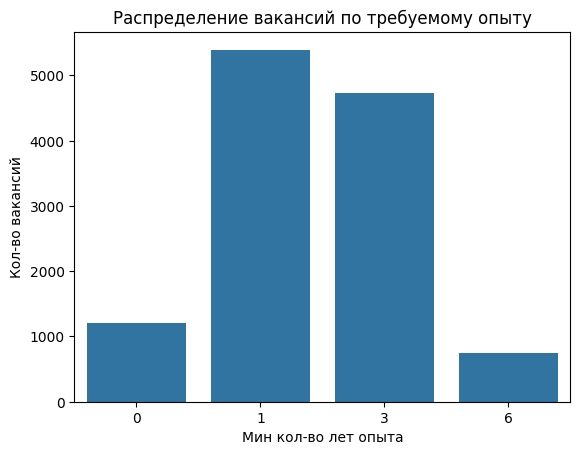

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='experience', data=final_df)
plt.title('Распределение вакансий по требуемому опыту')
plt.xlabel('Мин кол-во лет опыта')
plt.ylabel('Кол-во вакансий')
plt.show()

Для большинства ит-вакансий не требуют большого опыта. в основном это 1+ год.

### Region

In [ ]:
import plotly.express as px

region_10 = final_df['region'].value_counts()[:10]
fig = px.bar(region_10, title='Распределение ИТ-вакансий по регионам', )
fig.show()


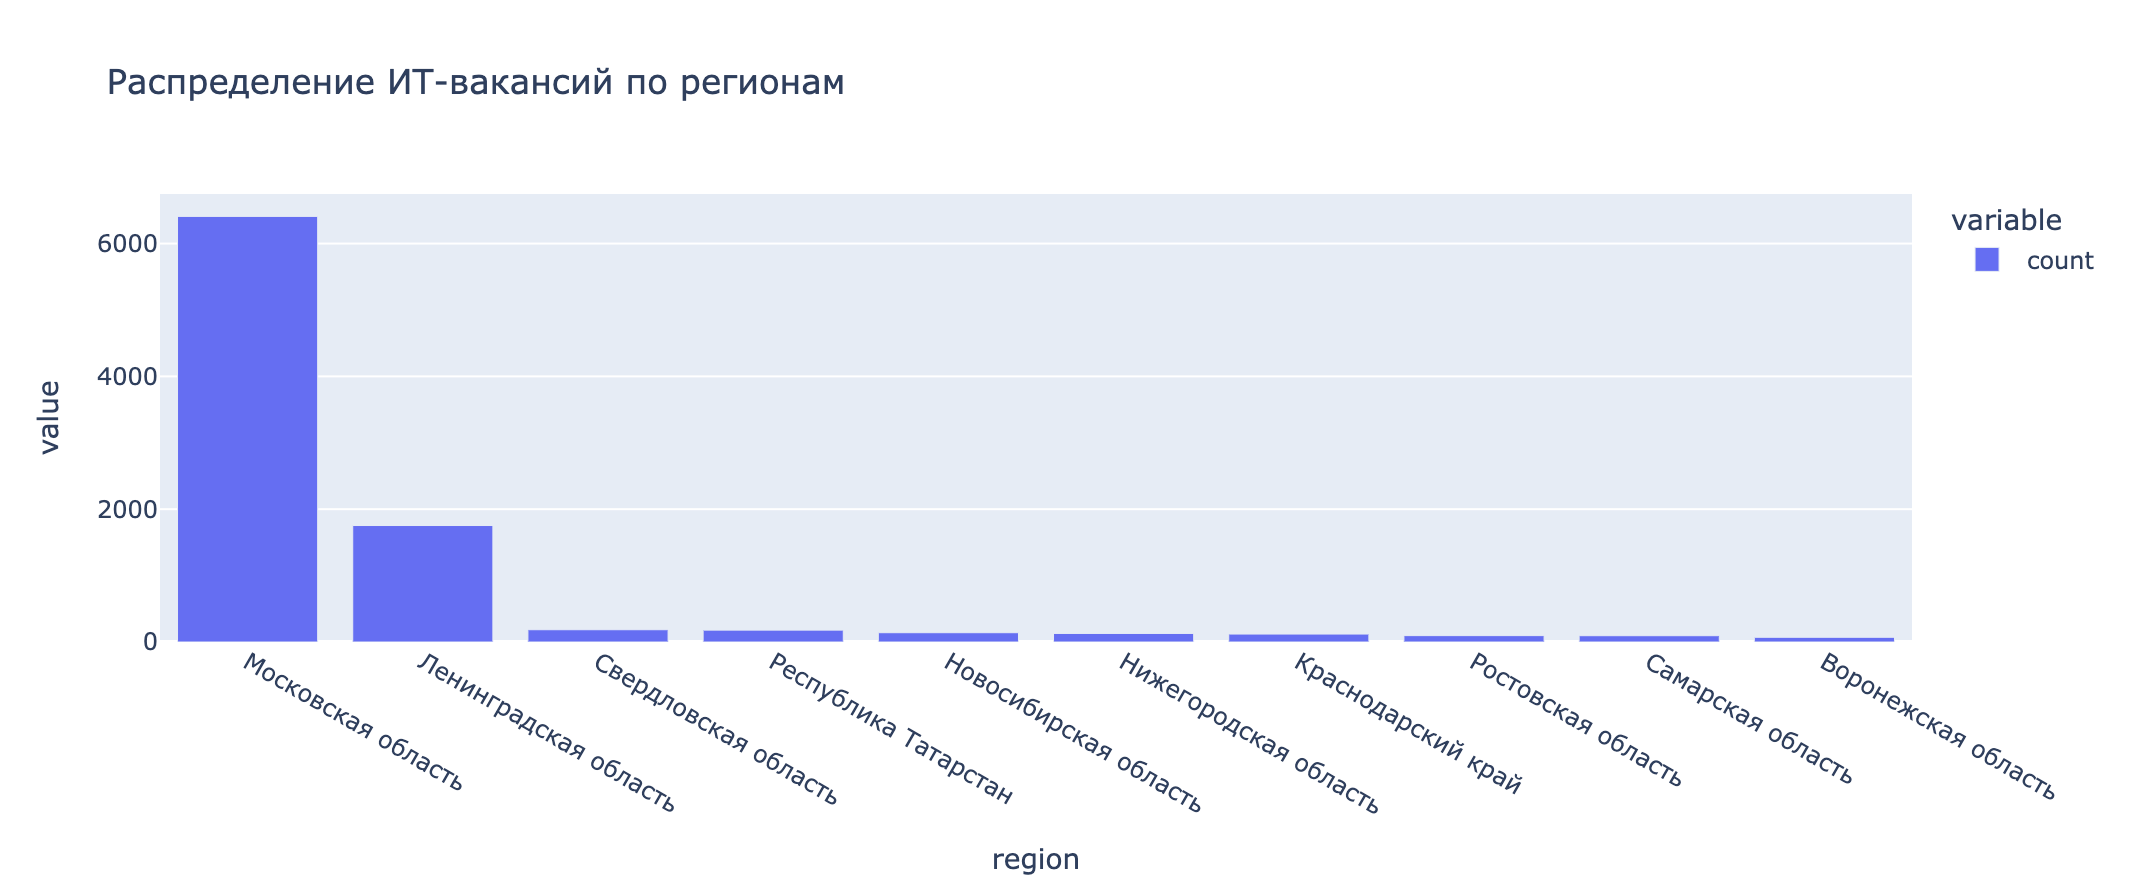

Ожидаемо Московская область и Москва (включена в мос область) лидируют. Далее Ленинградская область и остальные с большим отрывом от лидеров. В крупных городах вероятнее найти работу в ИТ-сфере.

### Education

In [133]:
import plotly.express as px
mask_edu = final_df['education'].notna()
data_pie = final_df.loc[mask_edu, 'education']
data_pie = data_pie.value_counts().reset_index()
fig = px.pie(data_pie, names='education', values='count', title='Распределение требуемых уровней образования')
fig.show()

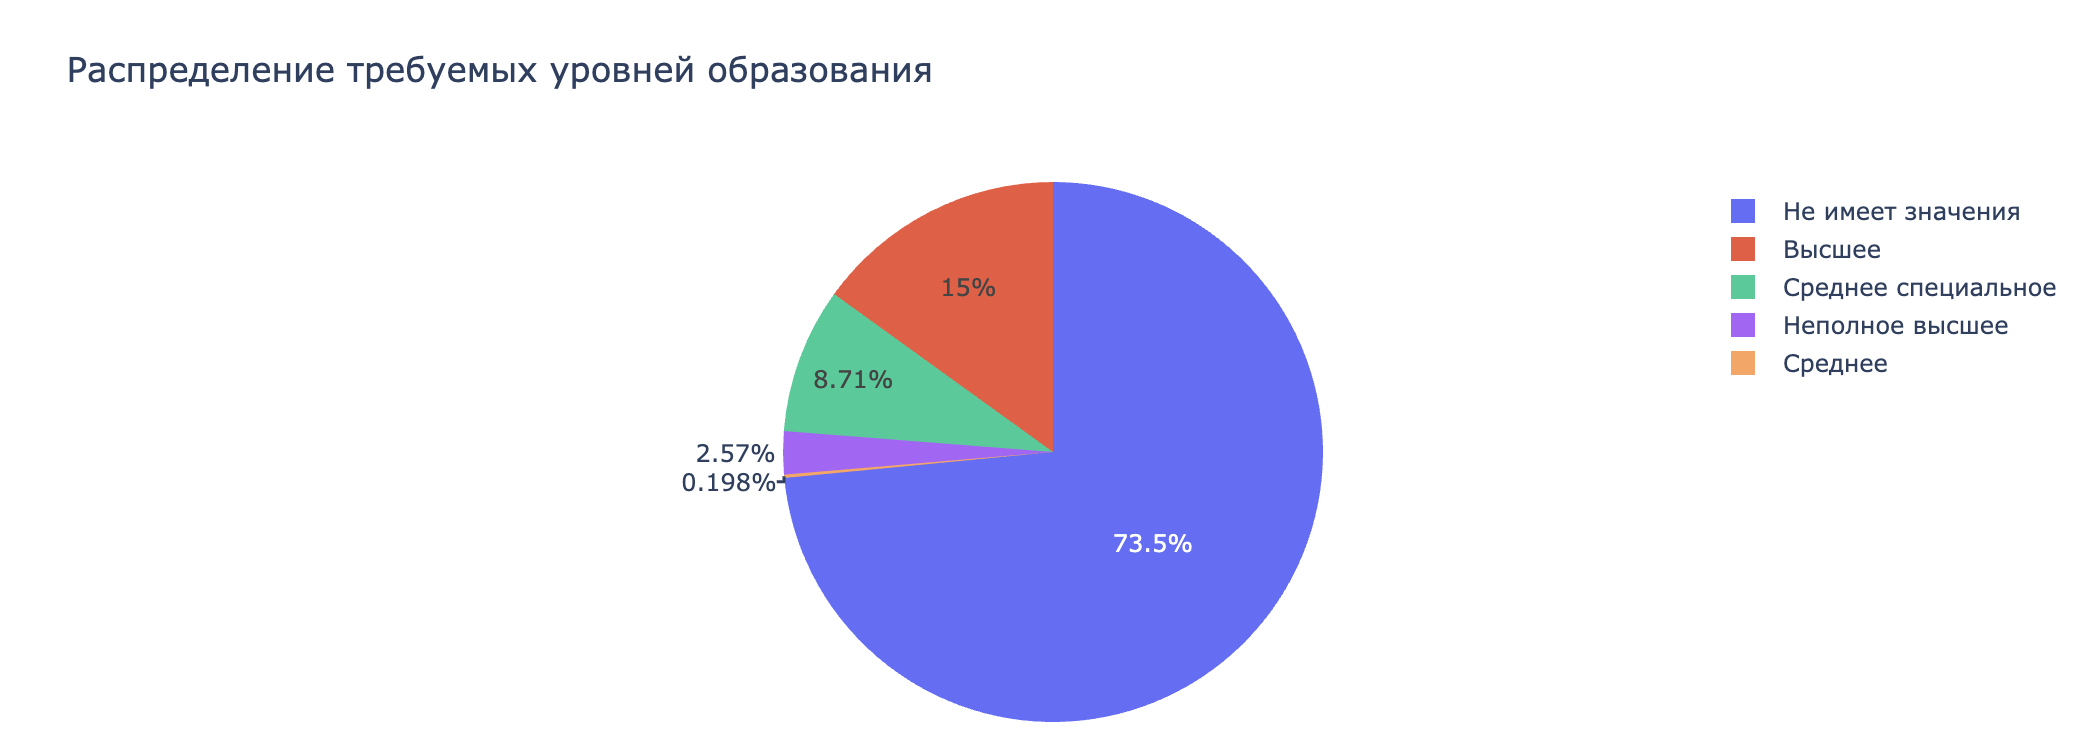

На графике видно, что для многих вакансий уровень образования не имеет значения.  

### Анализ целевой переменной - salary

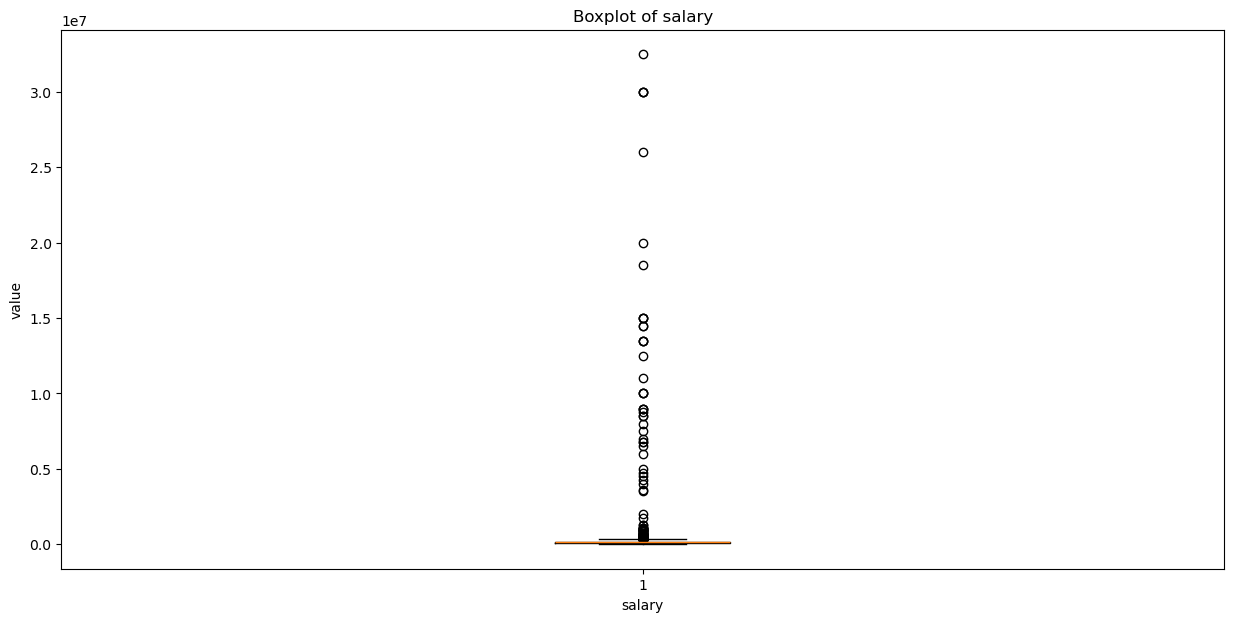

In [108]:
plt.figure(figsize=(15, 7))
mask_salary = final_df['salary'].notna() & final_df['salary']>0
plt.boxplot(final_df.loc[mask_salary, 'salary'])
plt.xlabel('salary')
plt.ylabel('value')
plt.title('Boxplot of salary')
plt.show()

На графике явно прослеживаются выбросы, где зп сильно превышает средний уровень, поэтому их необходимо обработать. Подберем перцентиль, по которому удалим лишние значения.

In [109]:
final_df.loc[mask_salary, 'salary'].quantile(0.98)

700000.0

In [110]:
mask_salary = final_df['salary'].notna() & final_df['salary']>0
num = final_df.loc[mask_salary, 'salary'].quantile(0.98)
big_salary_mask = final_df['salary'] > num
final_df = final_df[~big_salary_mask]

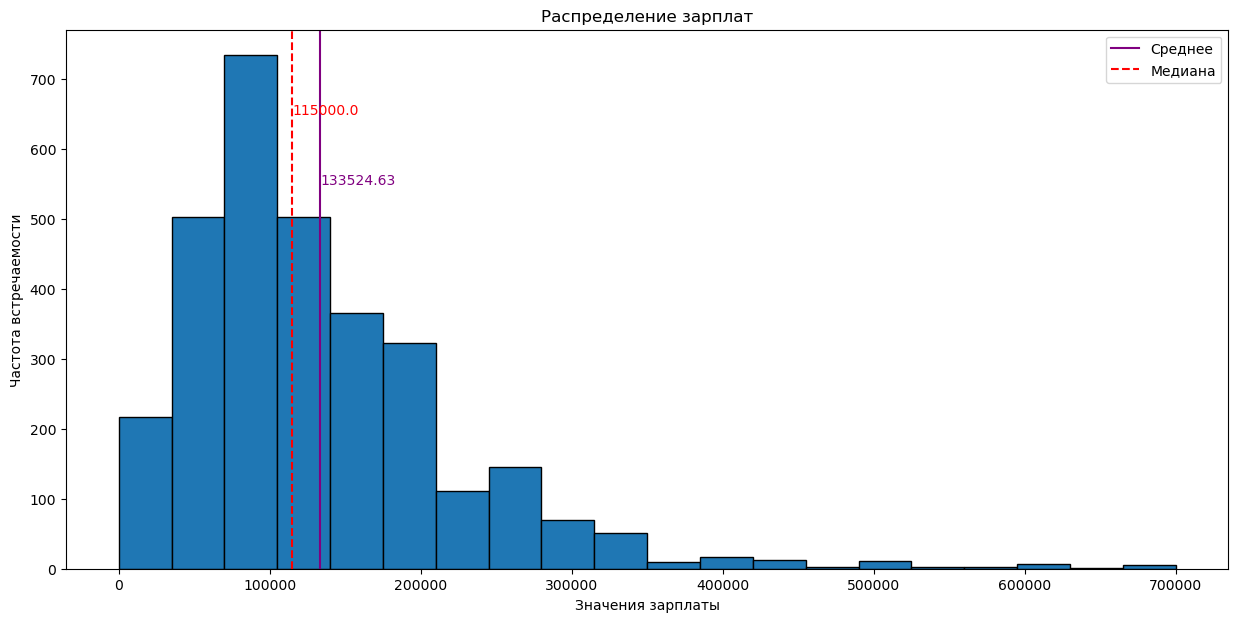

In [127]:
plt.figure(figsize=(15, 7))
mean_salary = final_df.loc[mask_salary, 'salary'].mean()
median_salary = final_df.loc[mask_salary, 'salary'].median()
plt.hist(final_df.loc[mask_salary, 'salary'], bins=20, edgecolor='black')
plt.xlabel('Значения зарплаты')
plt.ylabel('Частота встречаемости')
plt.title('Распределение зарплат')
plt.axvline(mean_salary, color='purple', linestyle='-', label='Среднее')
plt.axvline(median_salary, color='red', linestyle='--', label='Медиана')
plt.text(mean_salary+0.2, 550, round(mean_salary, 2), color='purple')
plt.text(median_salary+0.2, 650, median_salary, color='red')
plt.legend()
plt.show()

Медиана отличается от среднего значения, что доказывает смещенность данных, но это отражает действительность, так как на самом деле сущетсвуют вакансии с заметно более высокими зп, но гораздо реже.